In [ ]:
import torch
import pandas as pd 
import numpy as np

data_imatinib = torch.load("/home/tedeschg/prj/protein-perturbation/output_TEST/score_1/abl-imatinib_clean_1.pt", map_location="cpu")
data_decoy = torch.load("/home/tedeschg/prj/protein-perturbation/output_scoring/decoy_08_ZINC35543785_best_1.pt", map_location="cpu")
print(type(data_imatinib))
print(data_imatinib.keys() if hasattr(data_imatinib, "keys") else data_imatinib)

In [ ]:
probs_i = data_imatinib['probs']
order_i = data_imatinib['decoding_order']
alphabet_i = data_imatinib['alphabet']
native_seq_i = data_imatinib['native_sequence']
seq_i = data_imatinib['sequence']
res_i = data_imatinib['residue_names']

probs_d = data_decoy['probs']
order_d = data_decoy['decoding_order']
alphabet_d = data_decoy['alphabet']
native_seq_d = data_decoy['native_sequence']
seq_d = data_decoy['sequence']
res_d = data_decoy['residue_names']

In [ ]:
alphabet_dict = {i: aa for i, aa in enumerate(alphabet_i)}
print(alphabet_dict)

In [ ]:
seq_d

In [ ]:
diffs = [
    (i, a, b)
    for i, (a, b) in enumerate(zip(seq_d, seq_i))
    if a != b
]

for i, a, b in diffs:
    print(i, a, b)

# Probability each residue in the sequence

- here i mapped which is probability of the aminoacid which appear in the final sequence. The aminoacid is the one which has higher probability in 'probs'

In [ ]:
#for i in range(probs.shape[0]):
#    p = np.argmax(probs[i, 0])
#    print(f"Replica {i}, pos 0: {alphabet_dict[p]} ({probs[i, 0, p]:.4f})")

In [ ]:
#for i in range(probs.shape[0]):
#    for pos in range(probs.shape[1]):
#        p = np.argmax(probs[i][pos])
#        print(f"Replica {i}, pos {pos}: {alphabet_dict[p]} ({probs[i][pos][p]:.4f})")

In [ ]:
#n_reps = probs.shape[0]
#n_pos = probs.shape[1]

#rows = {}

#for i in range(n_reps):
#    aa_row = {}
#    prob_row = {}

#    for pos in range(n_pos):
#        p = np.argmax(probs[i, pos])
#        aa_row[f"pos{pos}"] = alphabet_dict[p]
#        prob_row[f"pos{pos}"] = probs[i, pos, p]

#    rows[f"aa_{i}"] = aa_row
#    rows[f"prob_{i}"] = prob_row

#df = pd.DataFrame(rows).T
#df.to_csv("/home/tedeschg/prj/side_projects/protein-perturbation/output/score_1/abl-imatinib_clean_1.csv", index=True)

# Each residue probability distribution

- Here i want to compare the probability distribution of each residue between two design with different ligand, and calculate ho much the probability distribution is perturbed, by calculating the KL-divergence of the probability distributions. 

- QUESTION 1 : can the perturbation be a proxy to consider if a ligand is good or not. I expect high perturbation, comparing with the real ligand, for bad ligand, small perturbation, better ligand.

- QUESTION 2 : can be considered the residue which has higher perturbation, comparing Free from ligand (P-MPNN) and with ligand (L-MPNN) a proxy to determine wether that residue is the one which can carry a mutation being pushed by that ligand ?


In [ ]:
import pandas as pd

replica = 0

df_i = pd.DataFrame(
    probs_i[replica],                 # shape (263, 21)
    columns=alphabet_i               # label corrette AA
)

df_i.index = [f"pos{i}" for i in range(probs_i.shape[1])]
#df_i.to_csv("/home/tedeschg/prj/protein-perturbation/output_TEST/score_1/replica0_all_probs.csv")


replica = 0

df_d = pd.DataFrame(
    probs_d[replica],                 # shape (263, 21)
    columns=alphabet_d               # label corrette AA
)

df_d.index = [f"pos{i}" for i in range(probs_d.shape[1])]
#df_d.to_csv("/home/tedeschg/prj/protein-perturbation/output_lmpnn_scoring/decoy/replica0_all_probs.csv")

## Fast ispection

In [ ]:
import matplotlib.pyplot as plt

res = 1

df_i.iloc[res].plot(kind="kde")
df_d.iloc[res].plot(kind="kde")

plt.title(f"Residue {res} distribution")
plt.xlabel("aa")
plt.ylabel("Prob")
plt.show()

# KL Divergence Analysis — Intact vs Decoy
### Per-residue comparison of LigandMPNN amino-acid probability distributions

This notebook computes **D_KL(P_intact ‖ P_decoy)** for every residue and visualises the results.

| Symbol | Meaning |
|--------|---------|
| `df_i` | Probability matrix for the **intact** structure (reference) |
| `df_d` | Probability matrix for the **decoy** structure |
| D_KL   | KL divergence — how much the decoy distribution diverges from intact |


$$D_{KL}(P \| Q) = \sum_{a} P(a) \log \frac{P(a)}{Q(a)}$$

- **P** = intact distribution (reference)  
- **Q** = decoy distribution (approximation)  
- A small `epsilon` is added to Q only, to avoid `log(0)` when the decoy assigns zero probability to an amino acid that the intact model does not.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import rel_entr

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## Computations

In [ ]:
EPSILON = 1e-10   # smoothing applied to Q only

def kl_divergence_per_residue(
    df_p: pd.DataFrame,
    df_q: pd.DataFrame,
    epsilon: float = EPSILON,
) -> pd.Series:
    """
    Compute D_KL(P || Q) row-wise (one value per residue).

    Parameters
    ----------
    df_p      : reference distribution DataFrame  (intact)
    df_q      : comparison distribution DataFrame (decoy)
    epsilon   : smoothing constant added to Q

    Returns
    -------
    pd.Series with one KL value per residue, same index as df_p.
    """
    P = df_p.values.astype(float)
    Q = df_q.values.astype(float)

    # Re-normalise rows to sum to 1 (guard against floating-point drift)
    P = P / P.sum(axis=1, keepdims=True)
    Q = Q / Q.sum(axis=1, keepdims=True)

    # Smooth Q, then renormalise so it stays a proper distribution
    Q_smooth = (Q + epsilon)
    Q_smooth = Q_smooth / Q_smooth.sum(axis=1, keepdims=True)

    # rel_entr(p, q) = p * log(p/q),  0 when p == 0
    kl_values = rel_entr(P, Q_smooth).sum(axis=1)

    return pd.Series(kl_values, index=df_p.index, name="KL_div")

In [ ]:
kl = kl_divergence_per_residue(df_i, df_d)

print(kl.describe().round(5))
print()
print("Top 10 residues with highest KL divergence:")
print(kl.nlargest(10).round(5))

In [ ]:
OUT_CSV = "/home/tedeschg/prj/protein-perturbation/kl_divergence_per_residue.csv"

kl.to_csv(OUT_CSV, header=True)
print(f"Saved → {OUT_CSV}")

## Visualize

### Plots

Two panels:
1. **Bar chart** — KL divergence along the sequence (spot regional hotspots)
2. **Ranked curve** — sorted KL values (useful for setting a threshold)

In [ ]:
OUT_PNG = "/home/tedeschg/prj/protein-perturbation/kl_divergence_per_residue.png"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7),
    gridspec_kw={"height_ratios": [2, 1]},
)

# ── Panel 1: along sequence ──────────────────────────────────────────────────
ax1.bar(range(len(kl)), kl.values, color="steelblue", alpha=0.85, width=1.0)
ax1.axhline(
    kl.mean(), color="crimson", linestyle="--", linewidth=1.3,
    label=f"Mean = {kl.mean():.4f}",
)
ax1.set_xlabel("Residue index")
ax1.set_ylabel(r"$D_{KL}(P_{intact} \| P_{decoy})$")
ax1.set_title(f"KL Divergence per residue  —  intact vs decoy  (replica {replica})")
ax1.legend()
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=20))

# ── Panel 2: sorted ──────────────────────────────────────────────────────────
kl_sorted = kl.sort_values(ascending=False).reset_index(drop=True)
ax2.plot(kl_sorted.values, color="darkorange", linewidth=1.5)
ax2.fill_between(range(len(kl_sorted)), kl_sorted.values, alpha=0.15, color="darkorange")
ax2.set_xlabel("Residue rank (highest KL first)")
ax2.set_ylabel(r"$D_{KL}$")
ax2.set_title("Sorted KL divergence")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_PNG}")


### Inspect a single residue

- Compare the full AA probability distribution for one residue (KDE plot).  
- Change `res` to inspect any position.

In [ ]:
res = 1   # ← change this

fig, ax = plt.subplots(figsize=(9, 4))
df_i.iloc[res].plot(kind="kde", ax=ax, label="intact", color="steelblue", linewidth=2)
df_d.iloc[res].plot(kind="kde", ax=ax, label="decoy",  color="darkorange", linewidth=2)

kl_val = kl.iloc[res]
ax.set_title(f"Residue {res}  —  D_KL = {kl_val:.4f}")
ax.set_xlabel("Amino acid probability")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


# Difference heatmap  P_intact − P_decoy

- Shows which amino acids gain or lose probability at each position.

In [ ]:
diff = df_i.subtract(df_d)   # shape (n_residues, 21)

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    diff.T,                  # (21 AA × n_residues)
    aspect="auto",
    cmap="RdBu",
    vmin=-0.3, vmax=0.3,
)
ax.set_yticks(range(len(diff.columns)))
ax.set_yticklabels(diff.columns, fontsize=8)
ax.set_xlabel("Residue index")
ax.set_title(r"$P_{intact} - P_{decoy}$  per amino acid per residue")
fig.colorbar(im, ax=ax, label="Probability difference")
plt.tight_layout()
plt.show()


## Final Score

In [ ]:
mean_kl = kl.mean()
sum_kl  = kl.sum()   

print(f"Number of residues  : {len(kl)}")
print(f"Mean KL (per res)   : {mean_kl:.5f}")
print(f"Sum KL  (total)     : {sum_kl:.5f}")
print()
print(f"→ Overall perturbation score : {mean_kl*100:.5f}")

active00 = 1.59742
active01 = 4.30359
active02 = 4.14316
active03 = 1.05465
active04 = 1.79627

decoy00 = 4.96189
decoy01 = 5.76479
decoy02 = 5.83375
decoy03 = 5.73901
decoy04 = 5.39957
decoy05 = 4.62055
decoy06 = 5.25906
decoy07 = 4.99112
decoy08 = 5.25414
decoy09 =


AUROC: 0.960


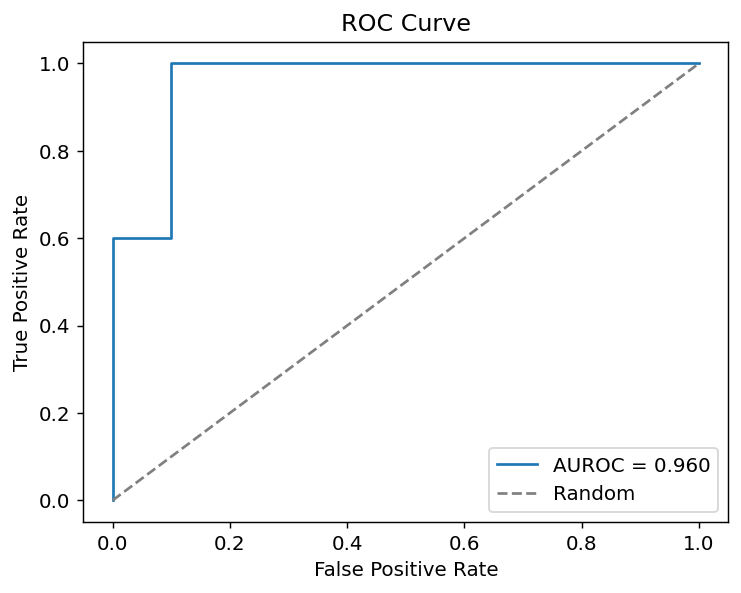

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

scores = [1.59742, 4.30359, 4.14316, 1.05465, 1.79627, 4.96189, 5.76479, 5.83375, 5.73901, 5.39957, 4.62055, 5.25906, 4.99112, 5.25414, 3.22106]   
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]    # 1=active, 0=decoy 

scores_neg = [-s for s in scores]
auroc = roc_auc_score(labels, scores_neg)
print(f"AUROC: {auroc:.3f}")

fpr, tpr, _ = roc_curve(labels, scores_neg)
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0,1], [0,1], "--", color="grey", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()